# Simulation Based Inference

The idea behind this notebook is to develop a framework to perform parameter estimation of the CSTR substandard data using SBI.

## Setup

Setting up engineering and physics-based model. 

In [1]:
%matplotlib inline

import numpy as np
import torch

# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt

# sbi
from sbi import utils as utils
from sbi.inference.base import infer
from sbi import analysis
from sbi.analysis import conditional_pairplot, conditional_corrcoeff

In [2]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
        
def cstr_model(t,y,params,inlet_conditions):
    
    C_i, T_i, T_ci,Q_c = inlet_conditions
    UA,k_0 = params
    C, T, T_c = y

    k = k_0*np.exp(-E_a/(R*T))
    
    dC_dt = (Q/V)*(C_i-C) - k*C
    dT_dt = (Q/V)*(T_i-T) - H_r*k*C/(rho*C_p) - UA*(T-T_c)/(rho*C_p*V)
    dTc_dt = (Q_c/V_c)*(T_ci - T_c) + UA * (T-T_c)/(rho_c*C_pc*V_c)
    
    return dC_dt, dT_dt, dTc_dt

In [3]:
import warnings
# Reactor constants
V = 150  # L
V_c =10 #    L
UA = 7E5#      cal/min/K
Q=100# L/min

# Reaction constants
E_a  = 83140#   J/mol 
R  = 8.314 #    J/K/mol 
H_r  =-2E5 #       cal/mol 
k_0  =7.2E10 #      1/min 

# Fluid constants
C_p = 1 # cal/g/k
C_pc  =1 #   cal/g/k 
rho = 1000 # g/L
rho_c = 1000 #g/l

def pre_simulator(inlet_conditions, params):
    """
    Simulator wrapper
    
    args:
        params(List): Parameters in the order of UA, k_0
    """
    
    y0 = [0.1, 430, 416]
    
    
    
    params_ext=[params[0]*1E5, params[1]*1E10]
    
    res = solve_ivp(cstr_model,(0,20),y0, method='RK45',args=(params_ext,inlet_conditions))
    
    sol = res.y
    output = sol[:,-1]
    
    # Check tolerance 
    abs_error = abs(output - sol[:,-5])
    rel_error = abs_error*100/y0
    error_percentage = 1

    
    if any(rel_error>error_percentage):
        warnings.warn(f'Solution not converged. {rel_error}', RuntimeWarning)
        return [np.nan, np.nan, np.nan]
    
    return output


pre_simulator([0.97, 351.5, 351.6, 150], [7,7.2])

array([1.07834438e-01, 4.28701704e+02, 4.14992781e+02])

## Comparing Simulator against itself

Answering the following questions:

* Can we use SBI to recover the true parameters of the model? 
* If not, then what are the caveats? 
* Sensitivity of key variables such as parameter limits and num of simulations?


Observations:
* True parameters can be recovered to a certain extent; we get a distribution where multiple values are possible. This can be interpreted as multiple parameter spaces that return the results that we expect; i.e. a higher k_0 requires a higher UA to maintain the same temperatures and concentrations. This has been confirmed with the simulator but now I am thinking if there needs to be some scaling...
* Some sensitivity to randomness can be seen across 100 simulations but with broadly similar results. 
    * There are some bad results that could be due to an unfortunate sampling of the parameter space for 100. 
    * 1000 simulations shows a similar strange variability from sample to sample; in fact the variability is larger which seems somewhat counter-intuitive. However the degree of correlation between the 2 parameters is much clearer to see.
    * 10000 simulations shows that the correlation is non-linear, and we seem to potentially get closer to the true parameter values. There is however a much more crazy distribution (multi-modal for some parameters). Would be interesting to see the variability of this. 
* I assume that an increase in the parameter limits will add to the variability. 

In [4]:
from functools import partial

simulator = partial(pre_simulator, [0.97, 351.5, 351.6, 150])
prior = utils.BoxUniform(low=[6,1], 
                         high=[10,10])

posterior = infer(simulator, prior, method='SNPE', num_simulations=100, num_workers=5)

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/scipy/integrate/_ivp/base.py:20: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return np.asarray(fun(t, y), dtype=dtype)


Running 100 simulations in 100 batches.:   0%|          | 0/100 [00:00<?, ?it/s]

 Neural network successfully converged after 102 epochs.

In [5]:
true_params = [7,7.2]

observation = simulator(true_params)
samples = posterior.sample((100000,), x=observation)

Drawing 100000 posterior samples:   0%|          | 0/100000 [00:00<?, ?it/s]

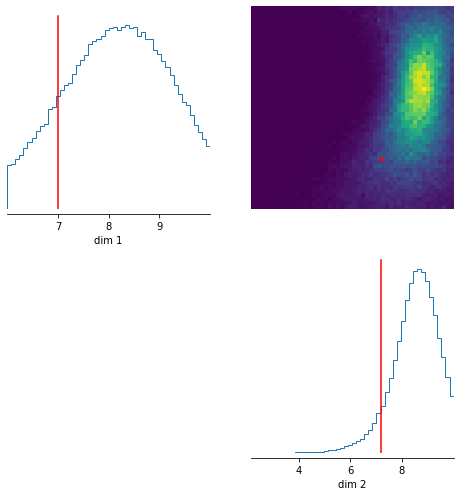

In [6]:
_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

In [7]:
true_params

[7, 7.2]

Running 100 simulations in 100 batches.:   0%|          | 0/100 [00:00<?, ?it/s]

 Neural network successfully converged after 56 epochs.

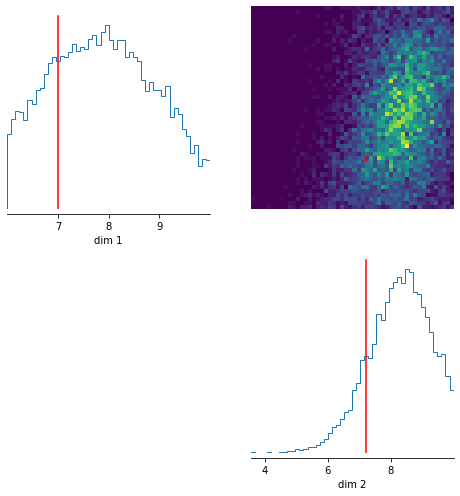

In [8]:
posterior = infer(simulator, prior, method='SNPE', num_simulations=100, num_workers=5)
samples = posterior.sample((10000,), x=observation,show_progress_bars=False)

_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      #limits=[[6E5,10E5]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 232 epochs.

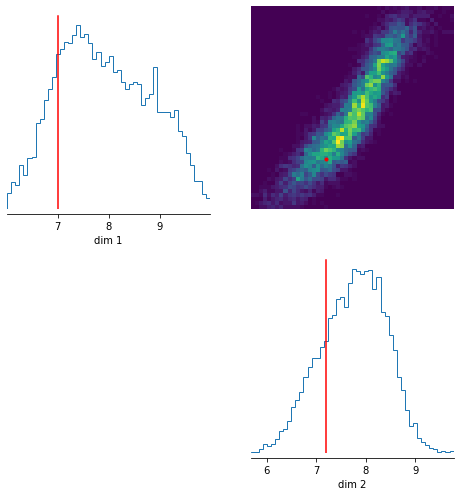

In [9]:
posterior = infer(simulator, prior, method='SNPE', num_simulations=1000, num_workers=5)
samples = posterior.sample((10000,), x=observation,show_progress_bars=False)

_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      #limits=[[6E5,10E5]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

In [10]:

def run_simulator(num_simulations=100):

    posterior = infer(simulator, prior, method='SNPE', num_simulations=num_simulations, num_workers=5)
    true_params = [UA,k_0]
    samples = posterior.sample((10000,), x=observation,show_progress_bars=False)
    return samples
    

In [18]:
store = []
for num_sim in range(10):

    samples = run_simulator()
    
    par_1 = [float(sample[0]) for sample in samples]
    par_2 = [float(sample[1]) for sample in samples]
    store.append([par_1,par_2])
  

Running 100 simulations in 100 batches.:   0%|          | 0/100 [00:00<?, ?it/s]

 Neural network successfully converged after 55 epochs.

Running 100 simulations in 100 batches.:   0%|          | 0/100 [00:00<?, ?it/s]

 Neural network successfully converged after 97 epochs.

Running 100 simulations in 100 batches.:   0%|          | 0/100 [00:00<?, ?it/s]

...

Running 100 simulations in 100 batches.:   0%|          | 0/100 [00:00<?, ?it/s]

 Neural network successfully converged after 119 epochs.

Running 100 simulations in 100 batches.:   0%|          | 0/100 [00:00<?, ?it/s]

 Neural network successfully converged after 86 epochs.

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.50887546 0.072951   0.13680043]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.96958941 0.08522075 0.04220418]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.05987971 0.04171003 0.08625061]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [3.97310654 0.06371781 0.19959088]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [7.456314   0.29540521 0.31415519]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [7.

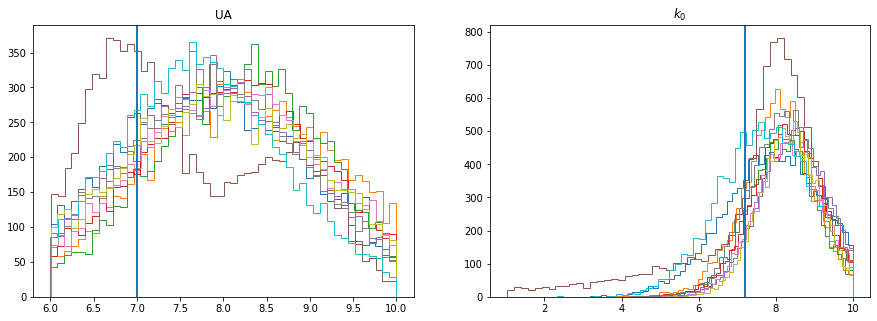

In [19]:
# Plotting the parameters  
plt.subplots(1,2,figsize=(15,5))

plt.subplot(1,2,1)
for item in store:
    plt.title('UA')
    _ = plt.hist(item[0],bins=50,histtype='step')
    plt.axvline(true_params[0])

plt.subplot(1,2,2)
for item in store:
    plt.title('$k_0$')
    _ = plt.hist(item[1],bins=50,histtype='step')
    plt.axvline(true_params[1])


In [20]:

store = []
for num_sim in range(10):

    samples = run_simulator(num_simulations=1000)
    
    par_1 = [float(sample[0]) for sample in samples]
    par_2 = [float(sample[1]) for sample in samples]
    store.append([par_1,par_2])
  

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 98 epochs.

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 173 epochs.

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 189 epochs.

Running 1000 simulations in 1000 batches.:   0%|          | 0/1000 [00:00<?, ?it/s]

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.08232483 0.03759007 0.11335088]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [3.45332198 0.0374645  0.10086261]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [3.15031344e+00 1.69748124e-02 3.10908983e-03]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.19385109 0.01979811 0.03968526]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [6.39522328 0.19716326 0.3173264 ]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not co

 Neural network successfully converged after 203 epochs.

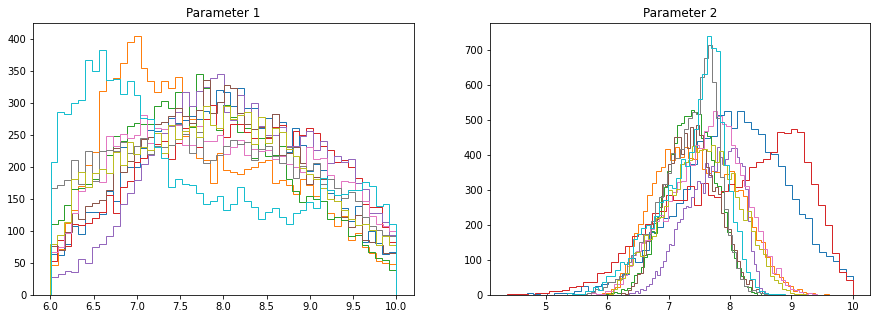

In [21]:
# Plotting the parameters  
plt.subplots(1,2,figsize=(15,5))

plt.subplot(1,2,1)
for item in store:
    plt.title('Parameter 1')
    _ = plt.hist(item[0],bins=50,histtype='step')
    #plt.axvline(UA)
    #plt.ylim([0,400])

plt.subplot(1,2,2)
for item in store:
    plt.title('Parameter 2')
    _ = plt.hist(item[1],bins=50,histtype='step')
    #plt.axvline(k_0)



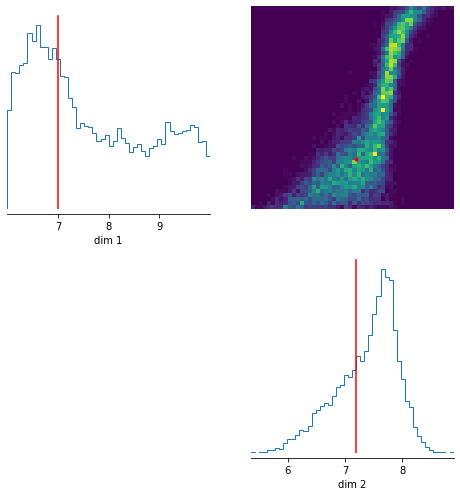

In [22]:
_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      #limits=[[6E5,10E5]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

In [23]:

store = []
for num_sim in range(1):

    samples = run_simulator(num_simulations=10000)
    
    par_1 = [float(sample[0]) for sample in samples]
    par_2 = [float(sample[1]) for sample in samples]
    store.append([par_1,par_2])
  

Running 10000 simulations in 10000 batches.:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [7.41678512 0.18225926 0.0966657 ]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [8.59490647 0.28077872 0.2729799 ]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.04724744 0.00992541 0.02662414]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [6.43419989 0.12698718 0.06291243]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [7.66120511 0.29504421 0.2385806 ]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [8.62645059 0.3242718  0.29992824]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [40.60219064  1.4173542   1.42993708]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [7.13914154 0.20232611 0.05035894]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [8.21450681 0.28326659 0.30358616]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.61550317 0.06931039 0.09742715]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. 

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.08015826 0.03420455 0.00883106]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.33930408 0.04895201 0.04994875]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.39298154 0.05106556 0.00758659]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.21769132 0.04159005 0.00137062]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.80568647 0.08499474 0.01627524]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.65958845 0.06750336 0.01615666]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.53478222 0.05711118 0.00689533]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.05994109e+00 3.51663911e-02 4.72508436e-04]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [5.03377943 0.0858804  0.03538834]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [9.16641889 0.36371353 0.32840246]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not co

...

 Training neural network. Epochs trained: 160

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.31451787 0.04483722 0.08271808]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [9.49871297 0.32150225 0.27369676]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [7.16676675e+00 2.06216170e-01 2.26781844e-03]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [9.25867297 0.12079535 0.04553901]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [4.98640141 0.08165599 0.05659684]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not co

 Training neural network. Epochs trained: 161

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.07268804 0.03963486 0.07719056]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.20960817 0.10559752 0.26760072]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.70121538 0.073457   0.00564651]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.4344439  0.05280582 0.07537118]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [6.80680881 0.18079412 0.20228357]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [7.

 Neural network successfully converged after 228 epochs.

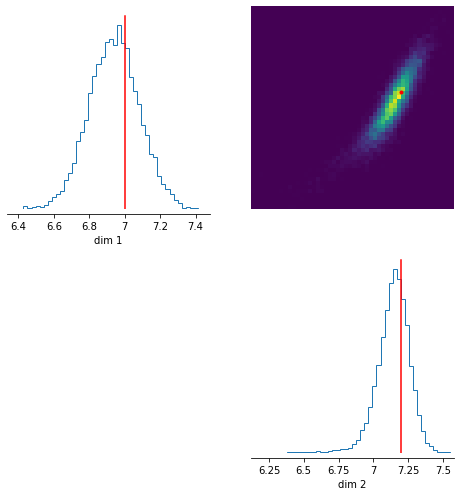

In [24]:
_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      #limits=[[6.5E5,7.5E5],[7e10,7.5e10]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )

In [25]:

store = []
for num_sim in range(1):

    samples = run_simulator(num_simulations=10000)
    
    par_1 = [float(sample[0]) for sample in samples]
    par_2 = [float(sample[1]) for sample in samples]
    store.append([par_1,par_2])
  

Running 10000 simulations in 10000 batches.:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.49985251 0.1003207  0.02709895]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.49374783 0.0628391  0.0414654 ]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [4.70751911 0.10349781 0.0308826 ]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [9.87704373 0.31718677 0.32096967]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.82992551 0.13100614 0.0366285 ]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [8.0022961  0.26986088 0.16498434]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.29183388 0.09449118 0.06182657]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.84384548 0.07971806 0.04024341]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [3.21058968 0.0439661  0.1564118 ]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.45136158 0.10795596 0.20758938]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [7.

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.37894184 0.05192579 0.00604039]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [7.9995386  0.16849487 0.10074506]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.35399882 0.0982493  0.05859166]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.69049875 0.07990086 0.02729686]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [3.56326339 0.16554546 0.27840574]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.

 Training neural network. Epochs trained: 108

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [6.76510386 0.18508232 0.30685141]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.2499527  0.04605055 0.03096979]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.05204546 0.03407333 0.05309295]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.33400687 0.04586765 0.0877453 ]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [7.31825104 0.22954108 0.23889975]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [4.

/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [8.65901219 0.28923089 0.186337  ]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.8589311  0.10014363 0.05543389]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [4.55657219 0.07872024 0.05623272]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [1.05452052 0.03556278 0.02793581]
/home/keepfloyding/miniconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: Solution not converged. [2.31406048 0.00724503 0.14663135]


 Neural network successfully converged after 174 epochs.

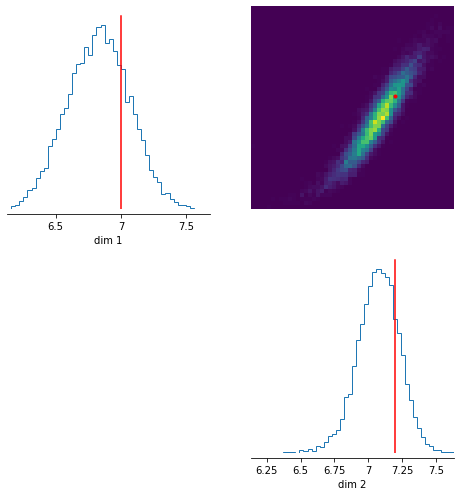

In [26]:
_ = analysis.pairplot(samples,
                      points=np.array(true_params),
                      figsize=(8,8),
                      #limits=[[6.5E5,7.5E5],[7e10,7.5e10]],
                      points_colors='r',
                      points_offdiag={'markersize': 6},
                     )